In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

decision_tree_estimators_dict = {
    "Decision Tree": estimators_dict["Decision Tree"],
    "Decision Tree Balanced": estimators_dict["Decision Tree Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_dt, threshold_comparison_dt, confusion_results_dt, trained_models_dt, interpretation_results_dt = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=decision_tree_estimators_dict,
    target=target
)

general_comparison_dt.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
9,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.5,0.744,0.350,0.690,0.464,0.760,0,9,24
7,Modelo 4 — Trajetória Organizacional,Decision Tree Balanced,0.5,0.753,0.347,0.606,0.441,0.728,0,8,22
15,Modelo 1 — Função Profissional Misto,Decision Tree Balanced,0.5,0.714,0.320,0.690,0.438,0.721,3,7,26
27,Modelo 7 — Reduzido Conservador Misto,Decision Tree Balanced,0.5,0.737,0.333,0.634,0.437,0.696,3,6,18
5,Modelo 3 — Faixa Salarial,Decision Tree Balanced,0.5,0.764,0.354,0.563,0.435,0.778,0,8,21
13,Modelo 7 — Reduzido Conservador,Decision Tree Balanced,0.5,0.705,0.310,0.676,0.425,0.728,0,7,18
23,Modelo 5 — Antiguidade Organizacional,Decision Tree Balanced,0.5,0.685,0.290,0.662,0.403,0.726,5,6,20
10,Modelo 6 — Perfil Pessoal,Decision Tree,0.5,0.855,0.600,0.296,0.396,0.763,0,9,24
17,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree Balanced,0.5,0.664,0.277,0.676,0.393,0.722,3,8,25
21,Modelo 4 — Experiência Profissional,Decision Tree Balanced,0.5,0.719,0.301,0.563,0.392,0.677,4,6,19


In [4]:
best_thresholds_dt = threshold_comparison_dt.loc[
    threshold_comparison_dt.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_dt.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
7,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree Balanced,0.650,0.821,0.455,0.563,0.503,0.722
18,Modelo 5 — Estabilidade e Benefícios,Decision Tree,0.275,0.821,0.452,0.535,0.490,0.768
4,Modelo 2 — Nível Hierárquico,Decision Tree,0.325,0.819,0.446,0.521,0.481,0.715
9,Modelo 3 — Faixa Salarial,Decision Tree Balanced,0.600,0.816,0.439,0.507,0.471,0.778
23,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Decision Tree Balanced,0.650,0.810,0.425,0.521,0.468,0.721
5,Modelo 2 — Nível Hierárquico,Decision Tree Balanced,0.625,0.810,0.425,0.521,0.468,0.731
19,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.475,0.744,0.350,0.690,0.464,0.760
8,Modelo 3 — Faixa Salarial,Decision Tree,0.225,0.798,0.404,0.535,0.461,0.774
20,Modelo 6 — Perfil Pessoal,Decision Tree,0.200,0.803,0.411,0.521,0.460,0.763
6,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree,0.225,0.828,0.463,0.437,0.449,0.726


In [5]:
top_5_best_dt = best_thresholds_dt.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_dt

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico e Benefícios,Decision Tree Balanced,0.650,0.821,0.455,0.563,0.503,0.722
1,Modelo 5 — Estabilidade e Benefícios,Decision Tree,0.275,0.821,0.452,0.535,0.490,0.768
2,Modelo 2 — Nível Hierárquico,Decision Tree,0.325,0.819,0.446,0.521,0.481,0.715
3,Modelo 3 — Faixa Salarial,Decision Tree Balanced,0.600,0.816,0.439,0.507,0.471,0.778
4,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Decision Tree Balanced,0.650,0.810,0.425,0.521,0.468,0.721


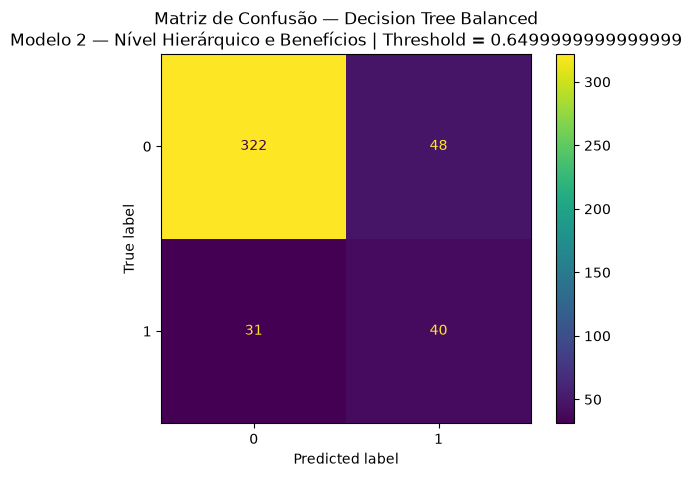

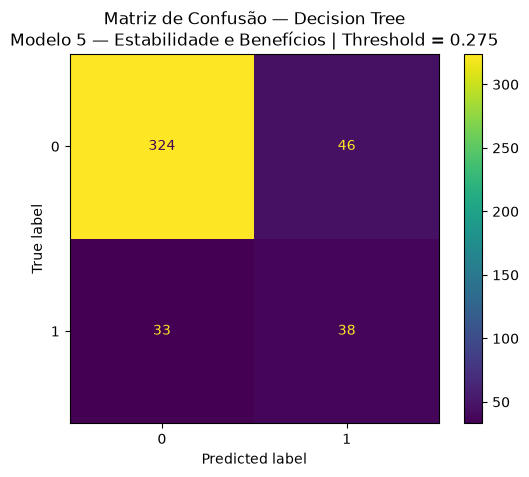

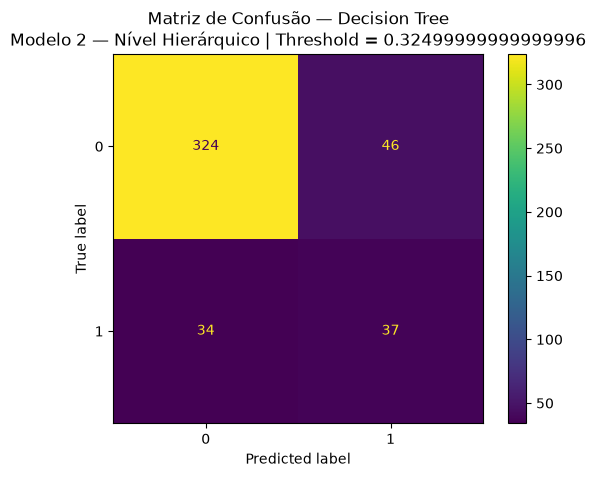

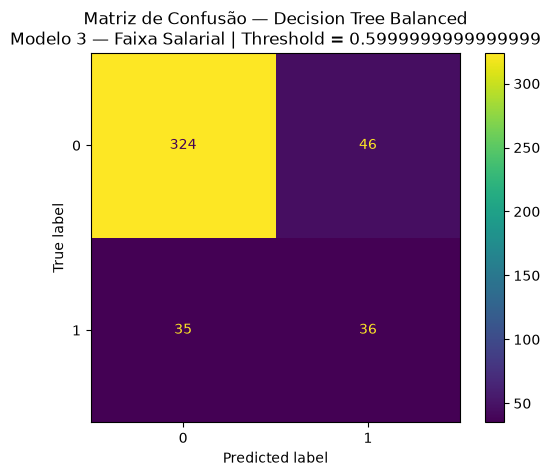

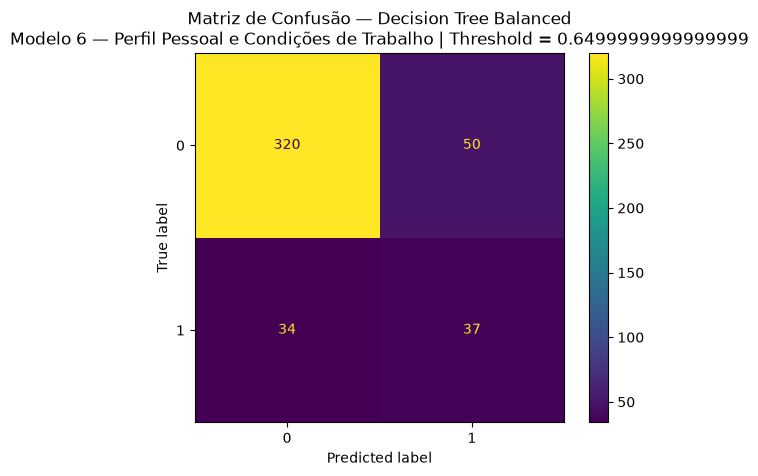

In [6]:
for _, row in top_5_best_dt.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(decision_tree_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

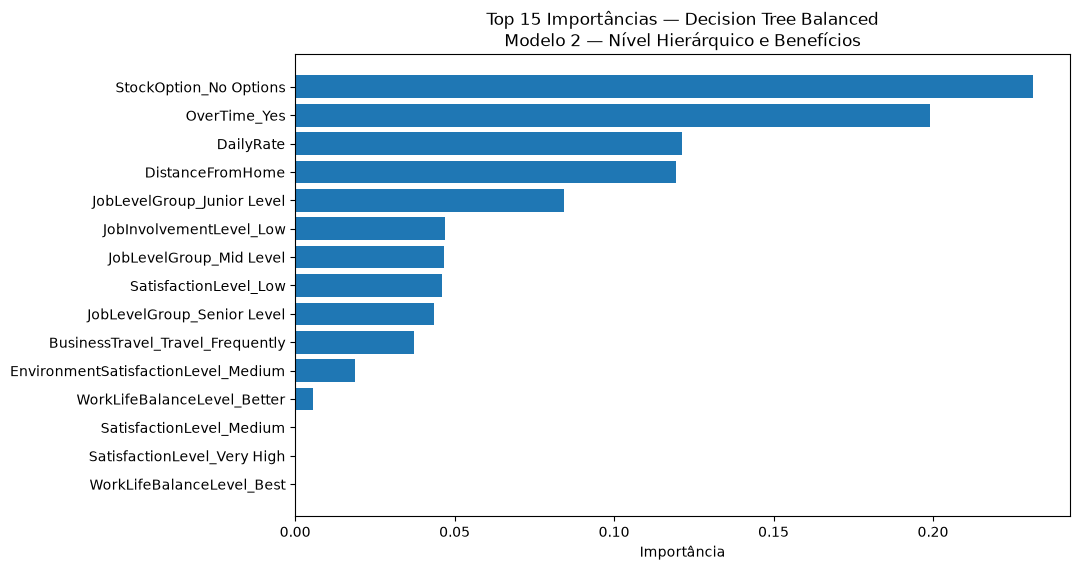

,Feature,Importance
10,StockOption_No Options,0.231435
3,OverTime_Yes,0.199029
1,DailyRate,0.121168
0,DistanceFromHome,0.119299
5,JobLevelGroup_Junior Level,0.084335
13,JobInvolvementLevel_Low,0.046886
6,JobLevelGroup_Mid Level,0.046751
19,SatisfactionLevel_Low,0.045985
7,JobLevelGroup_Senior Level,0.043480
11,BusinessTravel_Travel_Frequently,0.037320


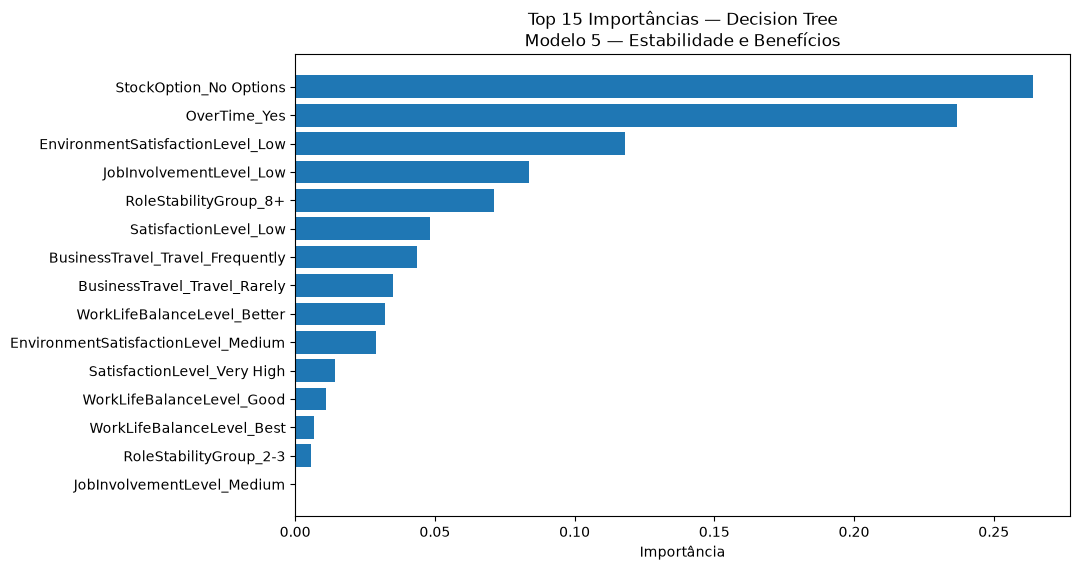

,Feature,Importance
6,StockOption_No Options,0.264134
0,OverTime_Yes,0.236962
12,EnvironmentSatisfactionLevel_Low,0.118055
9,JobInvolvementLevel_Low,0.083822
3,RoleStabilityGroup_8+,0.070999
15,SatisfactionLevel_Low,0.048337
7,BusinessTravel_Travel_Frequently,0.043683
8,BusinessTravel_Travel_Rarely,0.035062
19,WorkLifeBalanceLevel_Better,0.032262
13,EnvironmentSatisfactionLevel_Medium,0.029090


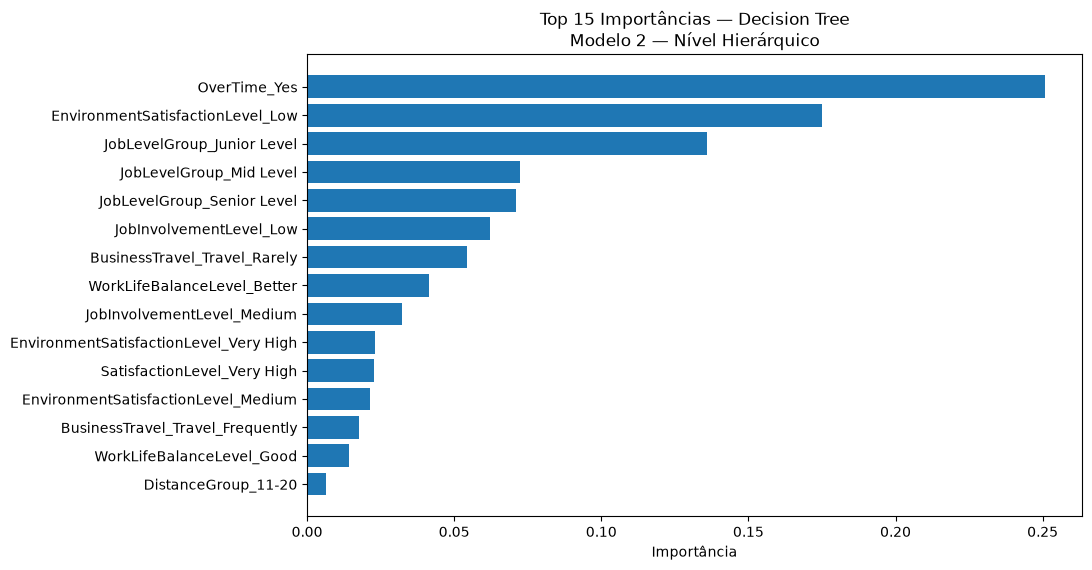

,Feature,Importance
0,OverTime_Yes,0.250861
10,EnvironmentSatisfactionLevel_Low,0.174911
2,JobLevelGroup_Junior Level,0.135943
3,JobLevelGroup_Mid Level,0.072315
4,JobLevelGroup_Senior Level,0.071038
7,JobInvolvementLevel_Low,0.062001
6,BusinessTravel_Travel_Rarely,0.054398
17,WorkLifeBalanceLevel_Better,0.041334
8,JobInvolvementLevel_Medium,0.032207
12,EnvironmentSatisfactionLevel_Very High,0.022952


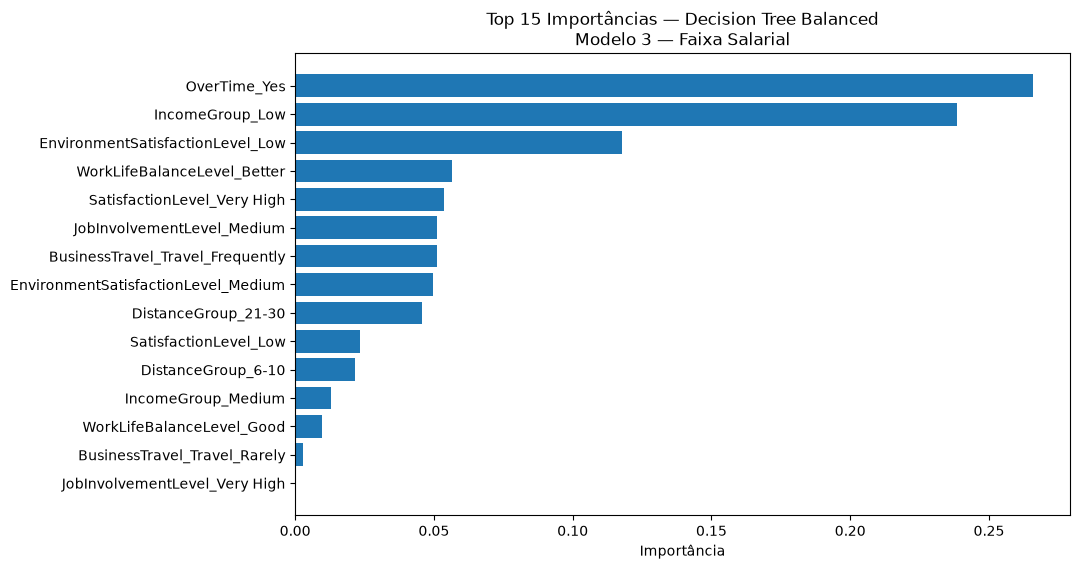

,Feature,Importance
0,OverTime_Yes,0.265943
1,IncomeGroup_Low,0.238291
9,EnvironmentSatisfactionLevel_Low,0.117838
16,WorkLifeBalanceLevel_Better,0.056365
14,SatisfactionLevel_Very High,0.053617
7,JobInvolvementLevel_Medium,0.051111
4,BusinessTravel_Travel_Frequently,0.051103
10,EnvironmentSatisfactionLevel_Medium,0.049784
19,DistanceGroup_21-30,0.045543
12,SatisfactionLevel_Low,0.023481


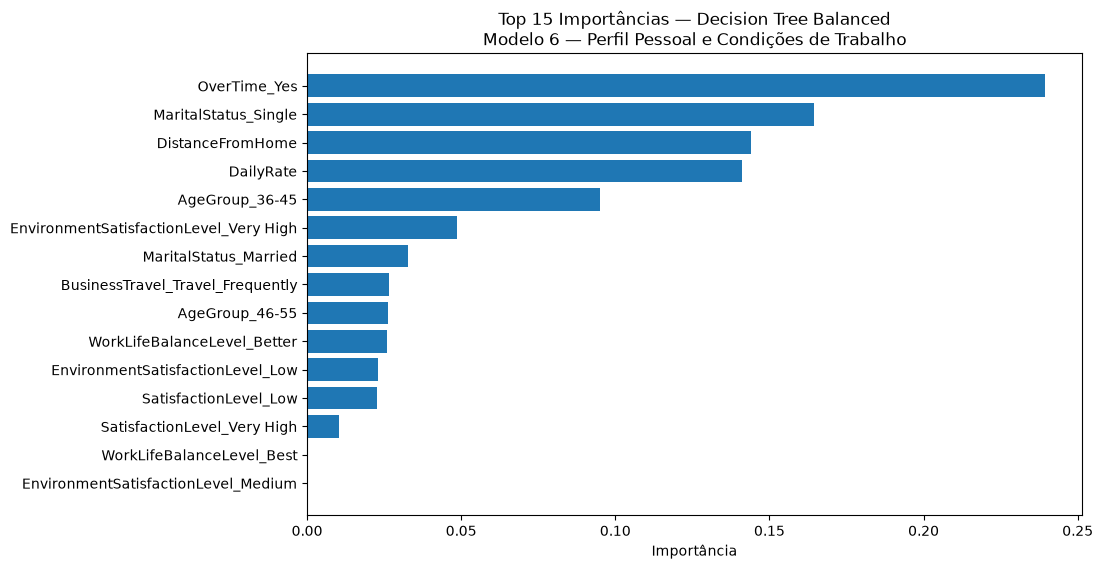

,Feature,Importance
3,OverTime_Yes,0.239449
9,MaritalStatus_Single,0.164503
0,DistanceFromHome,0.143975
1,DailyRate,0.141056
5,AgeGroup_36-45,0.094999
17,EnvironmentSatisfactionLevel_Very High,0.048550
8,MaritalStatus_Married,0.032812
10,BusinessTravel_Travel_Frequently,0.026589
6,AgeGroup_46-55,0.026305
22,WorkLifeBalanceLevel_Better,0.025783


In [7]:
for _, row in top_5_best_dt.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_dt[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — Decision Tree Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


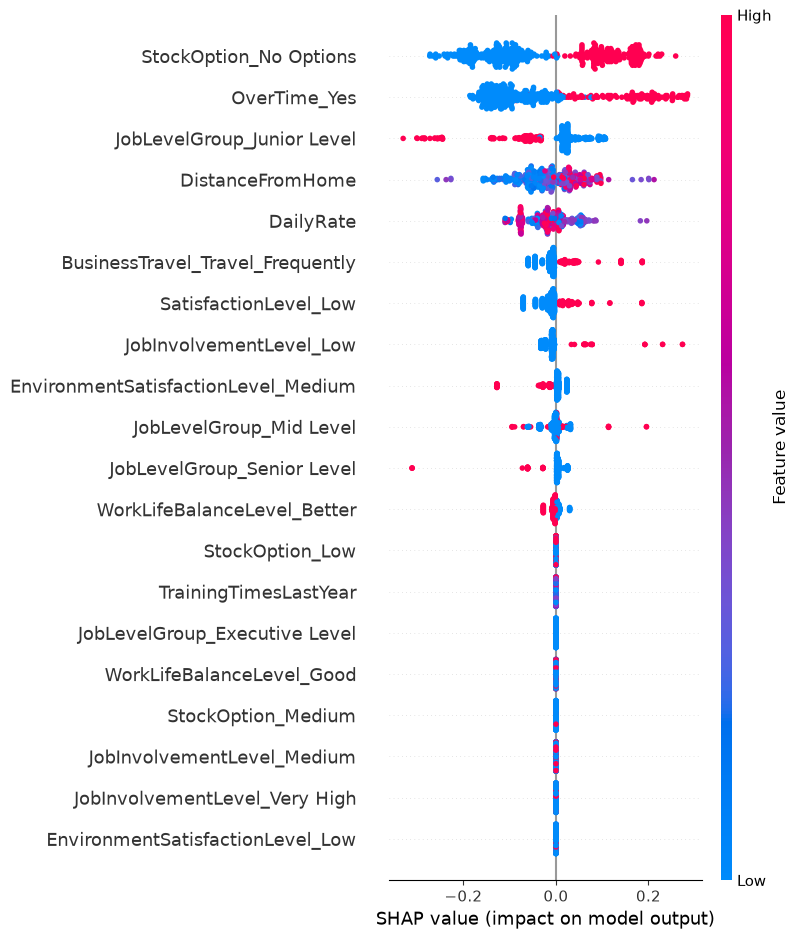

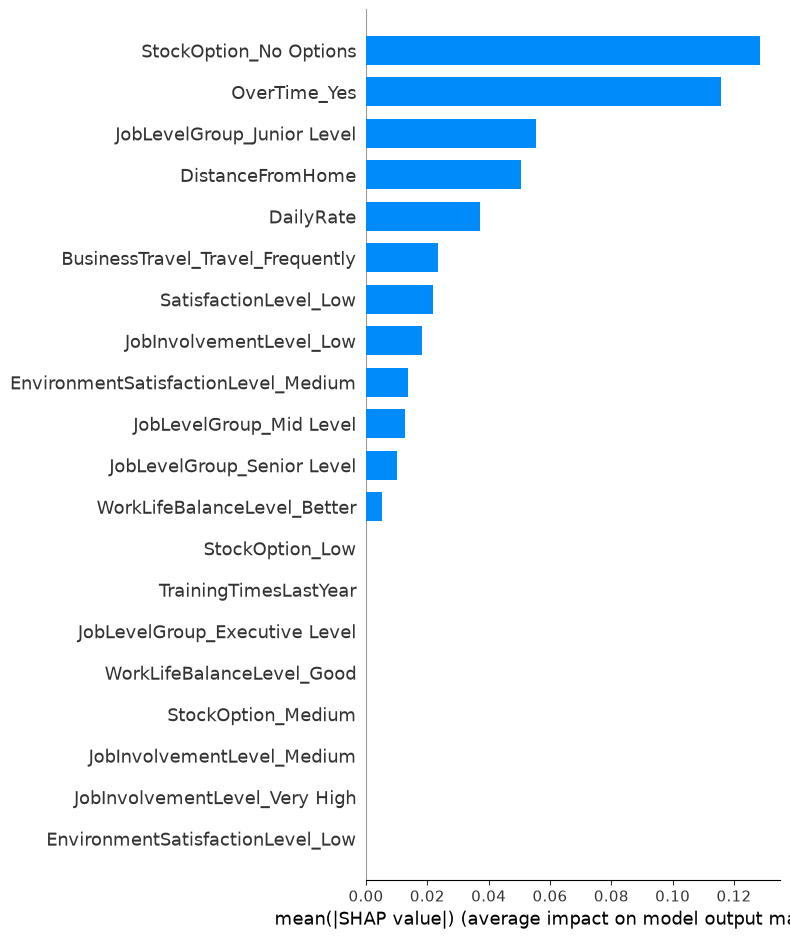

SHAP — Decision Tree | Modelo 5 — Estabilidade e Benefícios
(441, 24)
(441, 24)


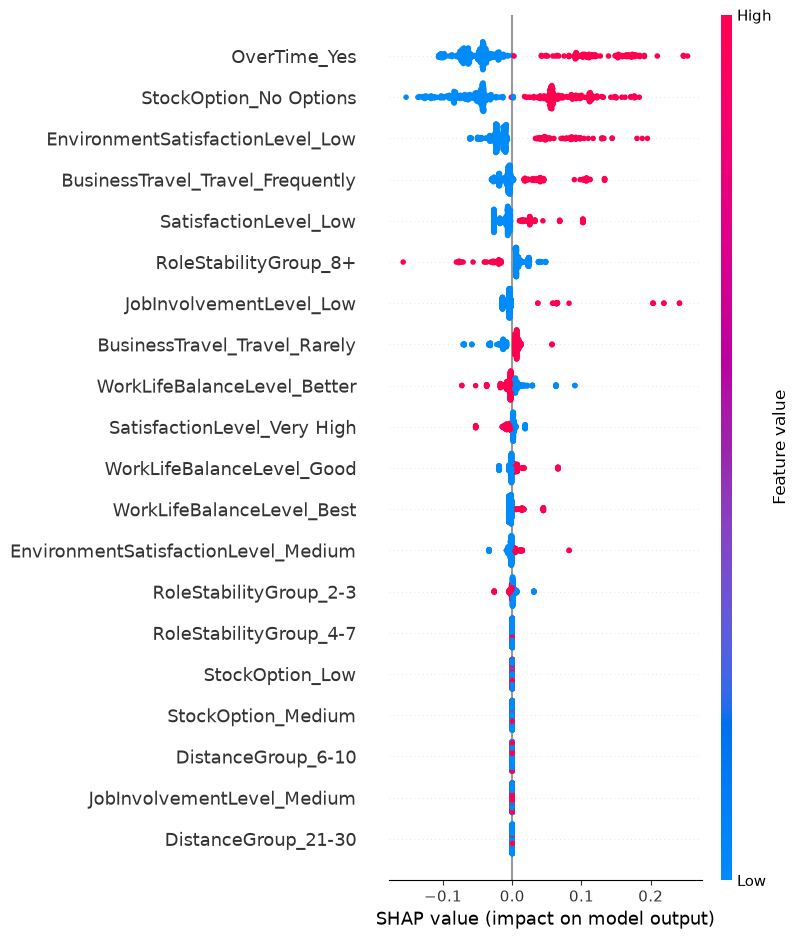

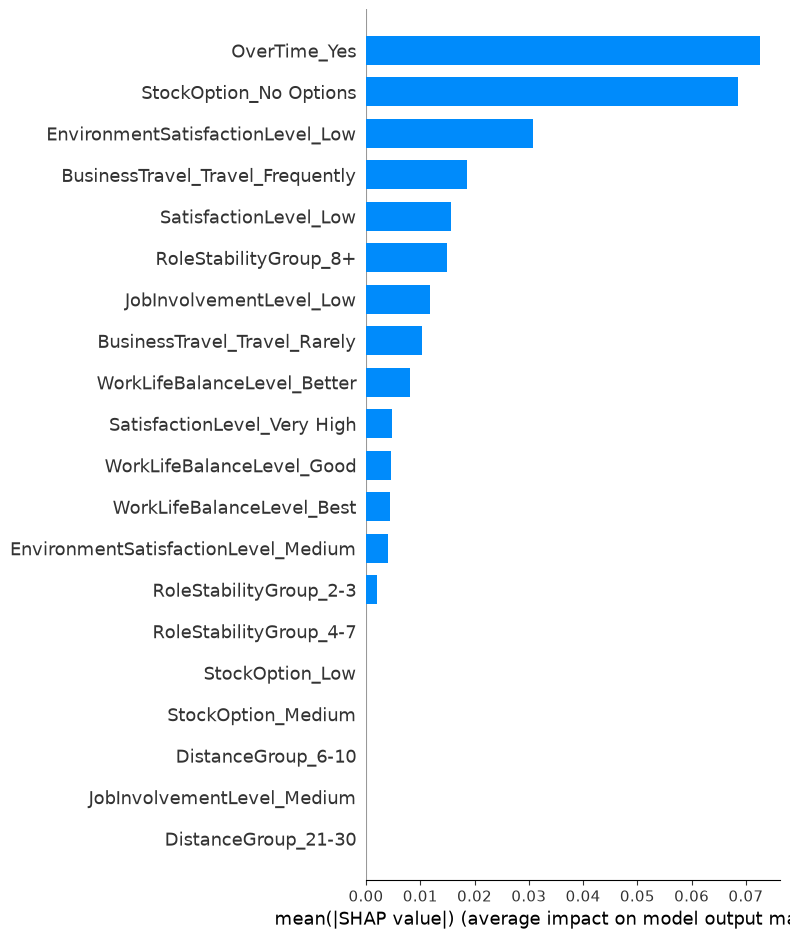

SHAP — Decision Tree | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


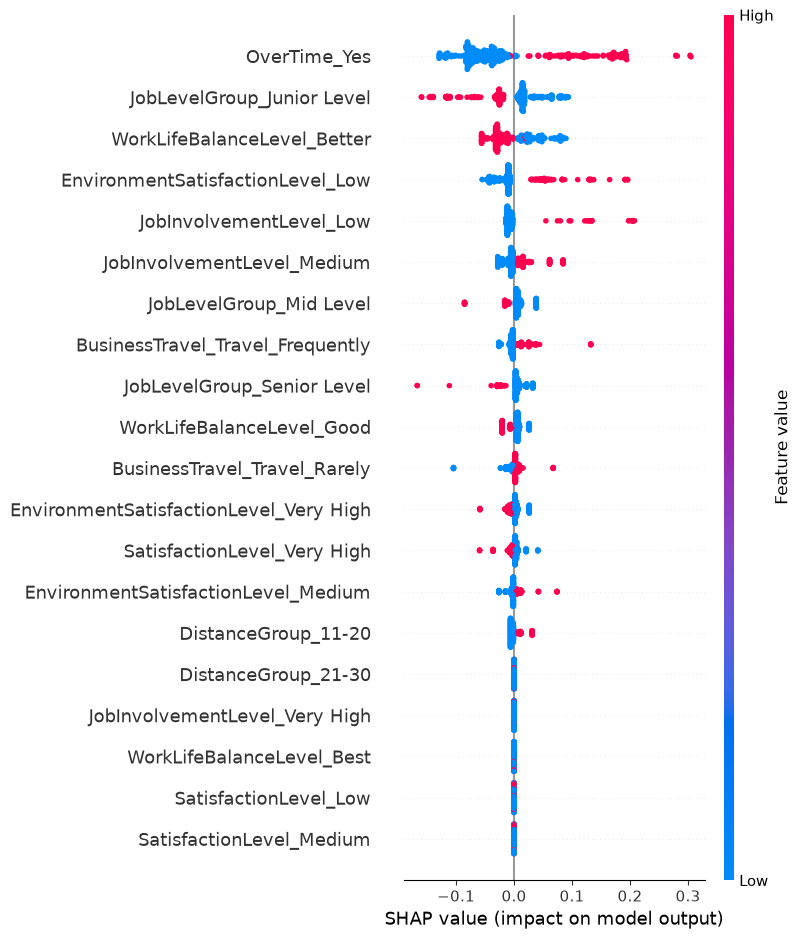

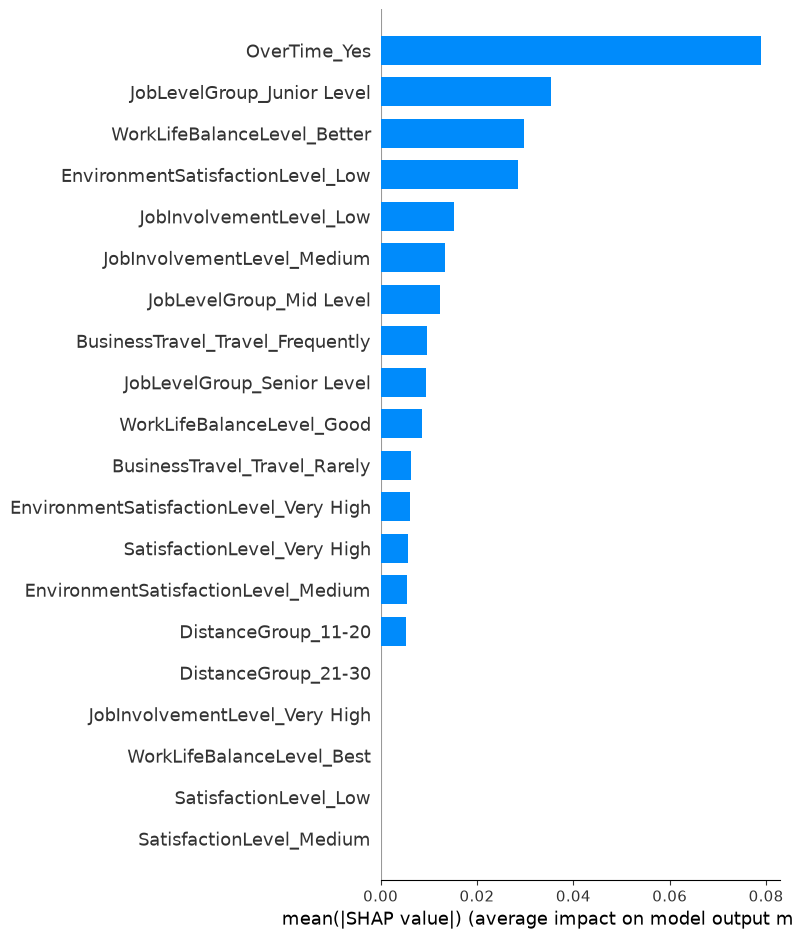

SHAP — Decision Tree Balanced | Modelo 3 — Faixa Salarial
(441, 21)
(441, 21)


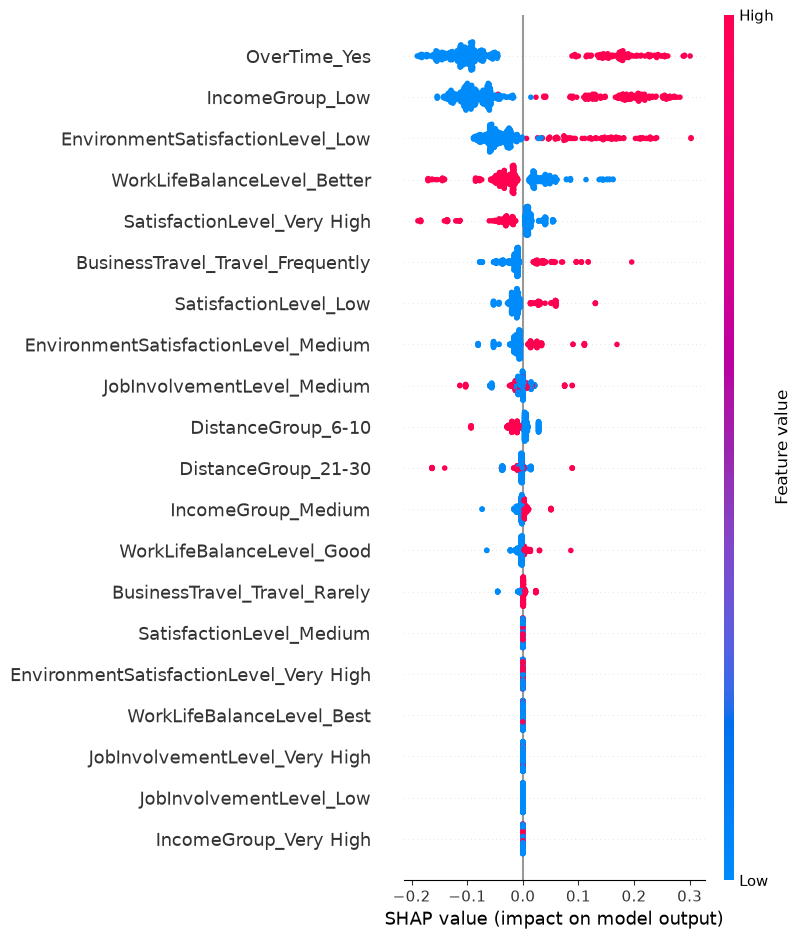

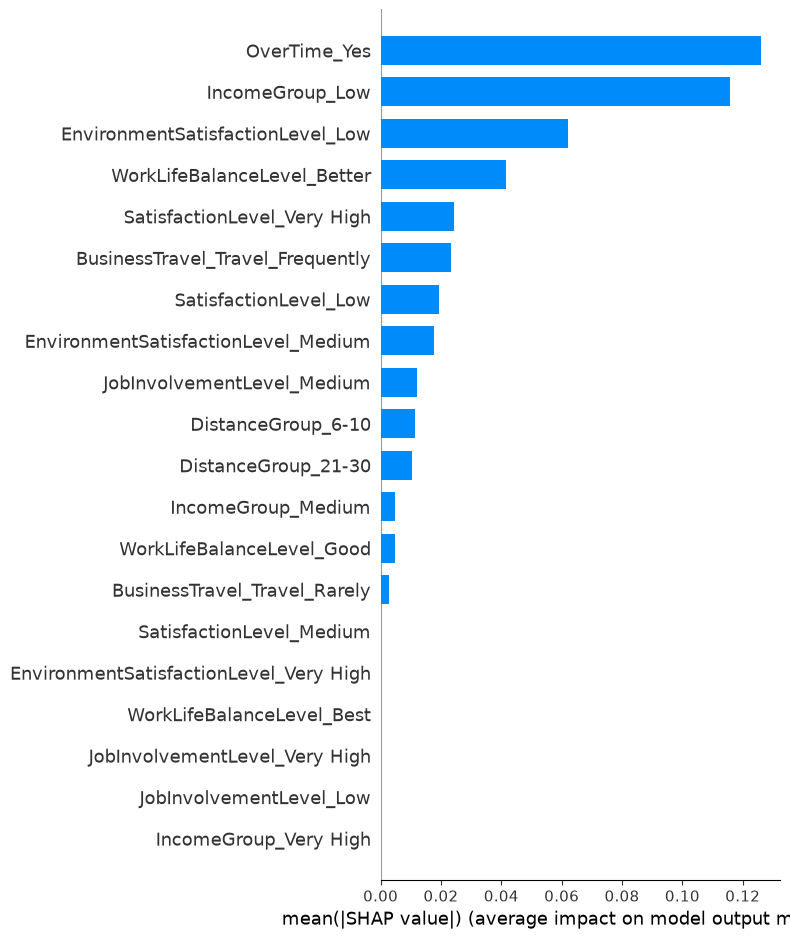

SHAP — Decision Tree Balanced | Modelo 6 — Perfil Pessoal e Condições de Trabalho
(441, 24)
(441, 24)


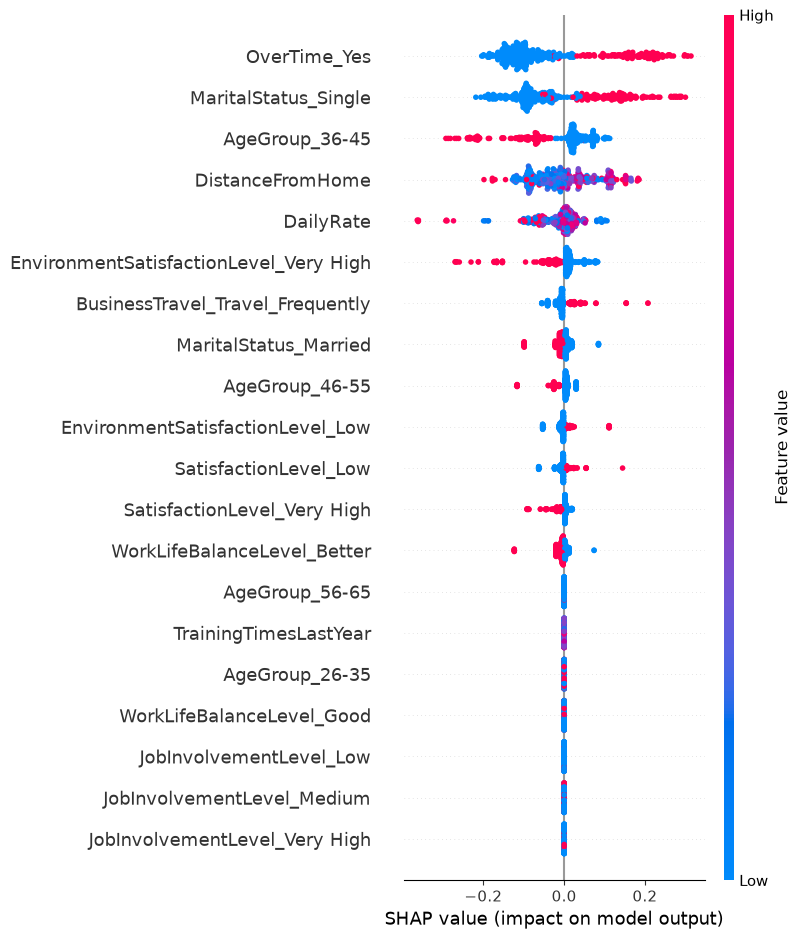

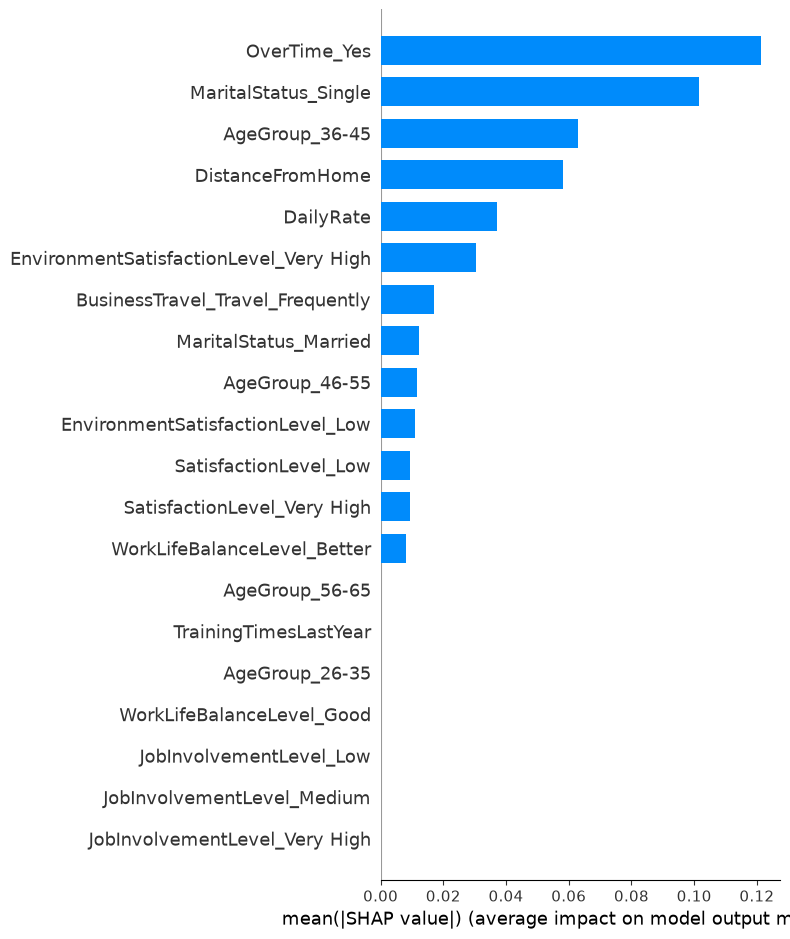

In [8]:
for _, row in top_5_best_dt.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(decision_tree_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_decision_tree = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Decision Tree": estimators_dict["Decision Tree"],
        "Decision Tree Balanced": estimators_dict["Decision Tree Balanced"]
    },
    target="AttritionFlag"
)

cv_decision_tree.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
28,Modelo 8 — Integrado Multidimensional,Decision Tree,0.848,0.019,0.553,0.116,0.350,0.096,0.422,0.087,0.726,0.046,7,11,43
29,Modelo 8 — Integrado Multidimensional,Decision Tree Balanced,0.737,0.030,0.324,0.044,0.578,0.122,0.412,0.057,0.708,0.060,7,11,43
9,Modelo 5 — Estabilidade e Benefícios,Decision Tree Balanced,0.718,0.043,0.312,0.049,0.599,0.086,0.408,0.053,0.696,0.046,0,9,24
21,Modelo 4 — Experiência Profissional,Decision Tree Balanced,0.737,0.059,0.329,0.082,0.540,0.087,0.403,0.075,0.691,0.078,4,6,19
5,Modelo 3 — Faixa Salarial,Decision Tree Balanced,0.705,0.047,0.301,0.058,0.590,0.085,0.395,0.052,0.724,0.052,0,8,21
1,Modelo 1 — Função Profissional,Decision Tree Balanced,0.694,0.038,0.292,0.039,0.616,0.066,0.395,0.042,0.710,0.050,0,8,26
7,Modelo 4 — Trajetória Organizacional,Decision Tree Balanced,0.697,0.065,0.298,0.051,0.600,0.081,0.394,0.048,0.716,0.036,0,8,22
19,Modelo 3 — Rendimento Quantitativo,Decision Tree Balanced,0.714,0.053,0.298,0.070,0.539,0.101,0.381,0.075,0.695,0.065,4,6,19
13,Modelo 7 — Reduzido Conservador,Decision Tree Balanced,0.693,0.057,0.289,0.066,0.573,0.102,0.379,0.065,0.690,0.061,0,7,18
23,Modelo 5 — Antiguidade Organizacional,Decision Tree Balanced,0.681,0.035,0.277,0.026,0.599,0.095,0.376,0.033,0.668,0.038,5,6,20
